# Chapter 1 — What We Are Actually Building

A language model can sound mysterious when we describe it with words like *understanding* or *thinking*.
To build one, we need a definition we can turn into code.

By the end of this chapter, you will be able to explain:

- what a language model predicts;
- how tokens, a vocabulary, and context define the prediction task;
- how scores become probabilities;
- how a decoding strategy chooses the next token; and
- how repeated next-token prediction generates text.

## What a Language Model Predicts

For this course, we will use one concrete definition:

> A language model takes previous tokens as context and produces a score for every token in its vocabulary that could come next.

Those scores can be converted into a probability distribution.
A separate **decoding strategy** then chooses or samples one token from that distribution.

Generation repeats three steps:

1. Use the current tokens as context.
2. Choose a next token from the model's output.
3. Append that token to the context.

The model does not generate an entire paragraph at once.
Long text emerges from repeating this small operation.

## Tokens, Vocabulary, and Context

Three terms define the model's input and output:

- A **token** is one piece of text processed as a unit.
  It may be a character, word, punctuation mark, or subword.
- The **vocabulary** is the finite set of tokens the model can represent and predict.
- The **context** is the sequence of previous tokens currently visible to the model.
  Real models have a maximum context length.

The examples in this chapter use word-like tokens because they are easy to read.
Our first learned models will use character tokens because their vocabularies and tokenizers are simpler.

Tokens are text units, not guaranteed units of meaning.
For example, a tokenizer might represent `unhappiness` as `un`, `happy`, and `ness`.

## Probability Distributions

Suppose the context is `The cat sat on the`.
A tiny vocabulary might contain five possible next tokens.
The model's output distribution assigns a probability to each one.

A valid probability distribution has two properties:

- every probability is between 0 and 1; and
- the probabilities add up to 1.

The following hand-written distribution is not learned.
It only makes the prediction task concrete.

In [1]:
import math
from collections.abc import Mapping

context_tokens = ("The", "cat", "sat", "on", "the")
next_token_probabilities: dict[str, float] = {
    "mat": 0.55,
    "floor": 0.20,
    "chair": 0.10,
    "roof": 0.05,
    "banana": 0.10,
}


def is_probability_distribution(
    probabilities: Mapping[str, float],
) -> bool:
    values_are_valid = all(0.0 <= value <= 1.0 for value in probabilities.values())
    total_is_one = math.isclose(sum(probabilities.values()), 1.0)
    return values_are_valid and total_is_one


print("Context:", " ".join(context_tokens))
print("Vocabulary:", list(next_token_probabilities))
print("Probabilities:", next_token_probabilities)
print("Total:", sum(next_token_probabilities.values()))
print("Valid distribution:", is_probability_distribution(next_token_probabilities))

Context: The cat sat on the
Vocabulary: ['mat', 'floor', 'chair', 'roof', 'banana']
Probabilities: {'mat': 0.55, 'floor': 0.2, 'chair': 0.1, 'roof': 0.05, 'banana': 0.1}
Total: 1.0
Valid distribution: True


## Choosing the Next Token

A model supplies scores or probabilities; it does not decide how generation should use them.
That decision belongs to the decoding strategy.

Two simple strategies are:

- **Greedy decoding:** always choose the highest-probability token.
  It is predictable but can become repetitive.
- **Random sampling:** choose tokens in proportion to their probabilities.
  It creates variety but can select unlikely tokens.

Python's `random.choices` accepts relative weights, so it can sample from numbers that do not sum to 1.
Here we pass a genuine probability distribution because that is what a language model represents after normalization.

In [2]:
import random

random_generator = random.Random(7)


def choose_greedily(probabilities: Mapping[str, float]) -> str:
    return max(probabilities, key=probabilities.__getitem__)


def sample_token(
    probabilities: Mapping[str, float],
    generator: random.Random,
) -> str:
    tokens = list(probabilities)
    weights = list(probabilities.values())
    return generator.choices(tokens, weights=weights, k=1)[0]


print("Greedy choice:", choose_greedily(next_token_probabilities))
print("Ten samples:")
for _ in range(10):
    print(sample_token(next_token_probabilities, random_generator))

Greedy choice: mat
Ten samples:
mat
mat
floor
mat
mat
mat
mat
mat
mat
mat


Sampling once can produce any token.
Sampling many times reveals the underlying distribution: frequent tokens should appear near their assigned probabilities.

Expected probabilities: {'mat': 0.55, 'floor': 0.2, 'chair': 0.1, 'roof': 0.05, 'banana': 0.1}
Observed frequencies: {'mat': 0.5533, 'floor': 0.1964, 'chair': 0.103, 'roof': 0.0477, 'banana': 0.0996}


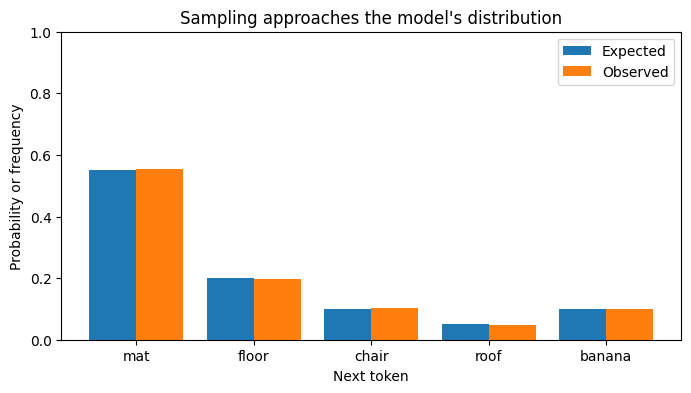

In [3]:
import matplotlib.pyplot as plt

sample_counts: dict[str, int] = dict.fromkeys(next_token_probabilities, 0)
number_of_samples = 10_000

for _ in range(number_of_samples):
    sampled_token = sample_token(next_token_probabilities, random_generator)
    sample_counts[sampled_token] += 1

sample_frequencies = {
    token: count / number_of_samples for token, count in sample_counts.items()
}
print("Expected probabilities:", next_token_probabilities)
print("Observed frequencies:", sample_frequencies)

tokens = list(next_token_probabilities)
positions = list(range(len(tokens)))
bar_width = 0.4
plt.figure(figsize=(8, 4))
plt.bar(
    [position - bar_width / 2 for position in positions],
    list(next_token_probabilities.values()),
    width=bar_width,
    label="Expected",
)
plt.bar(
    [position + bar_width / 2 for position in positions],
    list(sample_frequencies.values()),
    width=bar_width,
    label="Observed",
)
plt.xticks(positions, tokens)
plt.xlabel("Next token")
plt.ylabel("Probability or frequency")
plt.title("Sampling approaches the model's distribution")
plt.ylim(0, 1)
plt.legend()
plt.show()

The observed bars are close to the expected bars but not identical.
Random sampling varies from run to run; larger sample sizes usually reduce that difference.

## Scores, Logits, and Softmax

Neural language models produce one raw score for each vocabulary token.
These unnormalized scores are commonly called **logits**.
They may be positive, negative, or zero, and they do not need to add up to 1.

The **softmax** function converts logits into a probability distribution.
Before exponentiating, we subtract the largest logit.
This prevents numerical overflow and does not change the final probabilities because it shifts every logit by the same amount.

In [4]:
next_token_logits: dict[str, float] = {
    "mat": 3.2,
    "floor": 2.1,
    "chair": 1.4,
    "roof": 0.2,
    "banana": -1.0,
}


def softmax(logits: Mapping[str, float]) -> dict[str, float]:
    largest_logit = max(logits.values())
    exponentials = {
        token: math.exp(logit - largest_logit) for token, logit in logits.items()
    }
    total = sum(exponentials.values())
    return {token: value / total for token, value in exponentials.items()}


probabilities_from_logits = softmax(next_token_logits)
print("Logits:", next_token_logits)
print("Probabilities:", probabilities_from_logits)
print("Total:", sum(probabilities_from_logits.values()))

Logits: {'mat': 3.2, 'floor': 2.1, 'chair': 1.4, 'roof': 0.2, 'banana': -1.0}
Probabilities: {'mat': 0.6398146617204168, 'floor': 0.2129757998127953, 'chair': 0.10576065225025535, 'roof': 0.03185449630583613, 'banana': 0.009594389910696464}
Total: 1.0


## Generation as a Loop

The next example combines context lookup, sampling, token appending, and stopping.
It is still a hand-written table—not a trained model—but its control flow matches autoregressive generation.

A period acts as an explicit stop signal in this tiny example.
A small decoder also attaches punctuation without adding an incorrect space before it.
Real tokenizers define their own decoding rules.

In [5]:
from collections.abc import Sequence

manual_language_model: dict[tuple[str, ...], dict[str, float]] = {
    ("The", "cat", "sat", "on", "the"): {
        "mat": 0.70,
        "floor": 0.20,
        "chair": 0.10,
    },
    ("The", "cat", "sat", "on", "the", "mat"): {".": 1.0},
    ("The", "cat", "sat", "on", "the", "floor"): {".": 1.0},
    ("The", "cat", "sat", "on", "the", "chair"): {".": 1.0},
}


def decode_tokens(tokens: Sequence[str]) -> str:
    text = ""
    punctuation = {".", ",", "!", "?"}
    for token in tokens:
        if token in punctuation:
            text += token
        elif text:
            text += " " + token
        else:
            text = token
    return text


generated_tokens = ["The", "cat", "sat", "on", "the"]
print("Starting text:", decode_tokens(generated_tokens))

for step in range(10):
    current_context = tuple(generated_tokens)
    candidate_probabilities = manual_language_model.get(current_context)
    if candidate_probabilities is None:
        print("No continuation is defined. Stopping.")
        break

    next_token = sample_token(candidate_probabilities, random_generator)
    generated_tokens.append(next_token)
    print(f"Step {step + 1}: appended {next_token!r}")
    print("Current text:", decode_tokens(generated_tokens))

    if next_token == ".":
        print("The sentence is complete. Stopping.")
        break

Starting text: The cat sat on the
Step 1: appended 'mat'
Current text: The cat sat on the mat
Step 2: appended '.'
Current text: The cat sat on the mat.
The sentence is complete. Stopping.


## What Training Changes

A hand-written table cannot generalize beyond its exact entries.
Training replaces hand-written probabilities with values learned from many examples.

For the text `The cat sat on the mat`, one training example is:

- **Context:** `The cat sat on the`
- **Correct next token:** `mat`
- **Model output:** a probability for every vocabulary token

A model does better when it assigns more probability to the correct token.
A **loss** converts prediction quality into a number that training can minimize.
For one example, the common negative-log loss is `-log(probability of the correct token)`.

Bad prediction loss: 2.995732273553991
Better prediction loss: 0.35667494393873245


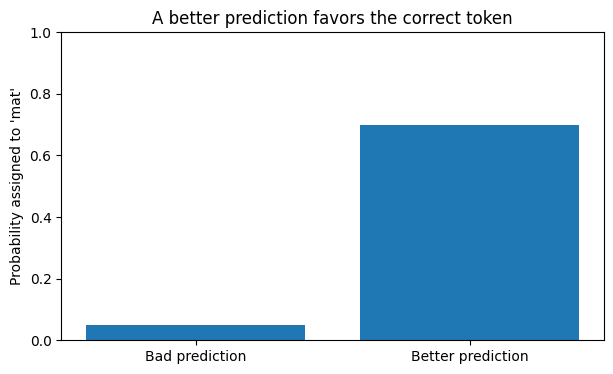

In [6]:
bad_prediction: dict[str, float] = {
    "mat": 0.05,
    "floor": 0.10,
    "chair": 0.10,
    "banana": 0.75,
}
better_prediction: dict[str, float] = {
    "mat": 0.70,
    "floor": 0.15,
    "chair": 0.10,
    "banana": 0.05,
}


def negative_log_loss(correct_token_probability: float) -> float:
    return -math.log(correct_token_probability)


bad_loss = negative_log_loss(bad_prediction["mat"])
better_loss = negative_log_loss(better_prediction["mat"])
print("Bad prediction loss:", bad_loss)
print("Better prediction loss:", better_loss)

labels = ["Bad prediction", "Better prediction"]
correct_token_probabilities = [bad_prediction["mat"], better_prediction["mat"]]
plt.figure(figsize=(7, 4))
plt.bar(labels, correct_token_probabilities)
plt.ylabel("Probability assigned to 'mat'")
plt.title("A better prediction favors the correct token")
plt.ylim(0, 1)
plt.show()

The better prediction assigns more probability to `mat`, so its loss is lower.
Training repeatedly adjusts model parameters to reduce this loss across many contexts.
Later chapters will derive the loss and show how those adjustments happen.

## What Next-Token Prediction Does Not Guarantee

Learning likely continuations is powerful, but it does not guarantee that generated text is:

- true;
- logically valid;
- useful for the reader; or
- safe or appropriate.

A language model learns statistical patterns in its training data.
Evaluating truth, reasoning, and behavior requires more than checking whether text is a likely continuation.

## Tiny Models and Large Models

The model built in this course will be small enough to train on a CPU with a modest public-domain dataset.
It will not behave like a commercial assistant.

Tiny educational models and large GPT-style models nevertheless share core components:

- text is converted into token IDs;
- token IDs are represented as vectors;
- a neural network produces next-token logits;
- softmax converts logits into probabilities; and
- a decoding strategy chooses the next token.

The major differences are scale, training data, compute, and engineering—not the basic prediction task.

## Key Takeaways

- A language model uses previous tokens as context and scores every possible next token in its vocabulary.
- Tokens are processing units and are not always whole words.
- Softmax converts logits into a probability distribution.
- Greedy decoding and random sampling are different ways to choose from that distribution.
- Text generation repeats next-token prediction one token at a time.
- Training lowers the loss by increasing probability on correct next tokens.
- Likely text is not automatically true or useful.

## Next Chapter

We now have a precise prediction task.
The next chapter will connect that task to the complete training process: preparing text, creating examples, measuring loss, updating parameters, and generating text with the trained model.